In [1]:
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA',
)

pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)
pseudotime_key = pseudotime.pseudotime_key
validity_key = pseudotime.validity_key

In [2]:
modules = ds.run_pseudotime_aggregation(
    cell_key=validity_key,
    pseudotime_key=pseudotime_key,
    cluster_label='pseudotime_clusters',
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)

In [3]:
# Number of retained features and pseudotime bins
modules.data.shape

(12396, 100)

In [4]:
pd.Series(modules.feature_clusters).value_counts().sort_index()

1      348
2     1150
3      537
4      820
5      296
6      727
7      675
8      482
9      909
10    1397
11     668
12    1035
13     887
14    1511
15     954
Name: count, dtype: int64

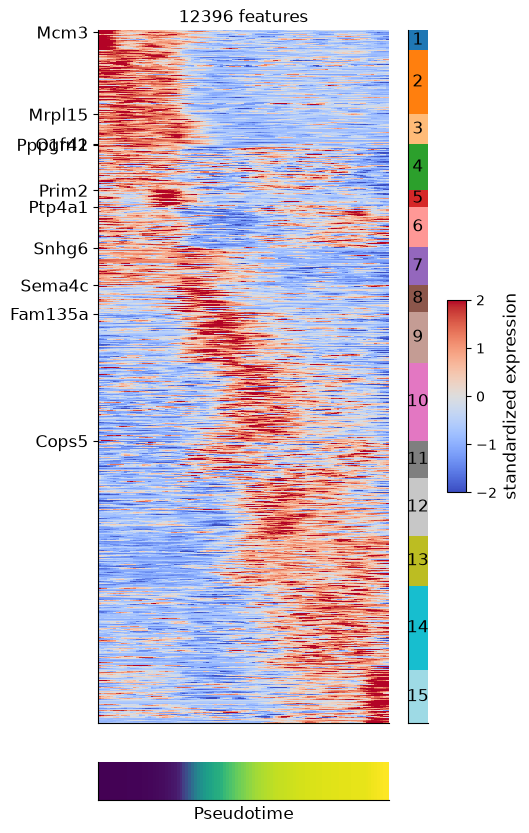

In [5]:
# One representative gene per retained module, derived from the aggregation result
ptime_feat = ds.RNA.feats.to_pandas_dataframe(
    columns=['names', modules.cluster_key]
)
assigned = ptime_feat[ptime_feat[modules.cluster_key] != -1]
genes_to_label = (
    assigned.groupby(modules.cluster_key, sort=True)['names']
    .first()
    .head(10)
    .tolist()
)
genes_to_label

ds.plots.pseudotime_heatmap(
    cell_key=modules.cell_key,
    feat_key=modules.feature_key,
    feature_cluster_key=modules.cluster_key,
    pseudotime_key=modules.pseudotime_key,
    show_features=genes_to_label,
)

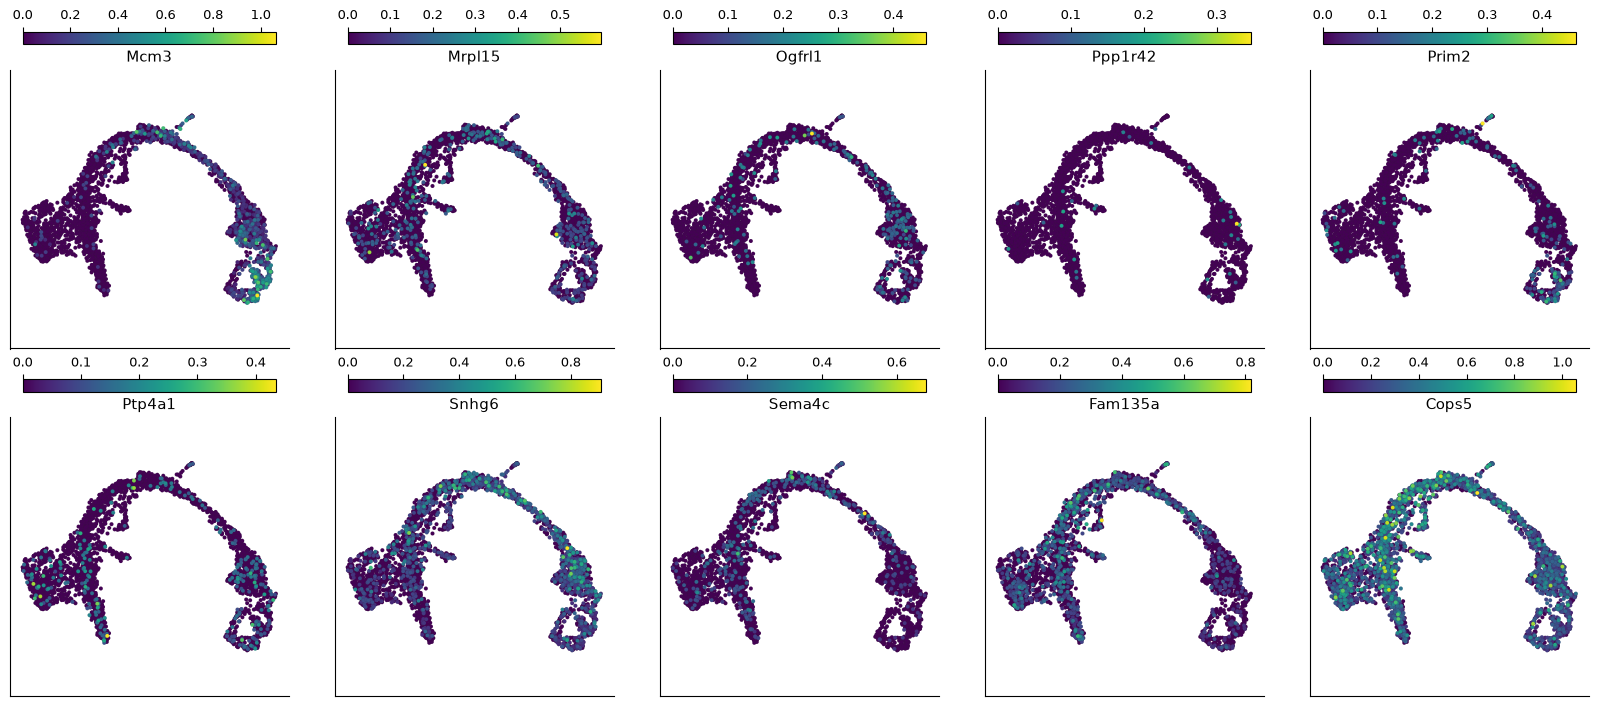

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=genes_to_label,
    n_columns=5,
    sort_values=True,
)

In [7]:
ds.add_grouped_assay(
    group_key=modules.cluster_key,
    assay_label='PTIME_MODULES'
)

In [8]:
ds

DataStore has 3413 (3696) cells with 2 assays: PTIME_MODULES RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_nFeatures', 
            'RNA_percentRibo', 'RNA_pseudotime__valid', 'G2M_score', 'PTIME_MODULES_nCounts', 'RNA_pseudotime', 
            'RNA_G2M_score', 'RNA_UMAP2', 'RNA_S_score', 'RNA_nCounts', 'RNA_cell_cycle_phase', 
            'S_score', 'RNA_cluster', 'PTIME_MODULES_nFeatures', 'clusters', 'clusters_coarse', 
            'RNA_UMAP1'
   PTIME_MODULES assay has 15 (15) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'highly_variable_genes', 
            'pseudotime_clusters', 'dropOuts', 'I__hvgs'

In [9]:
ds.PTIME_MODULES.feats.head()

,I,ids,names,dropOuts,nCells
0,True,group_1,group_1,0,3696
1,True,group_2,group_2,0,3696
2,True,group_3,group_3,0,3696
3,True,group_4,group_4,0,3696
4,True,group_5,group_5,0,3696


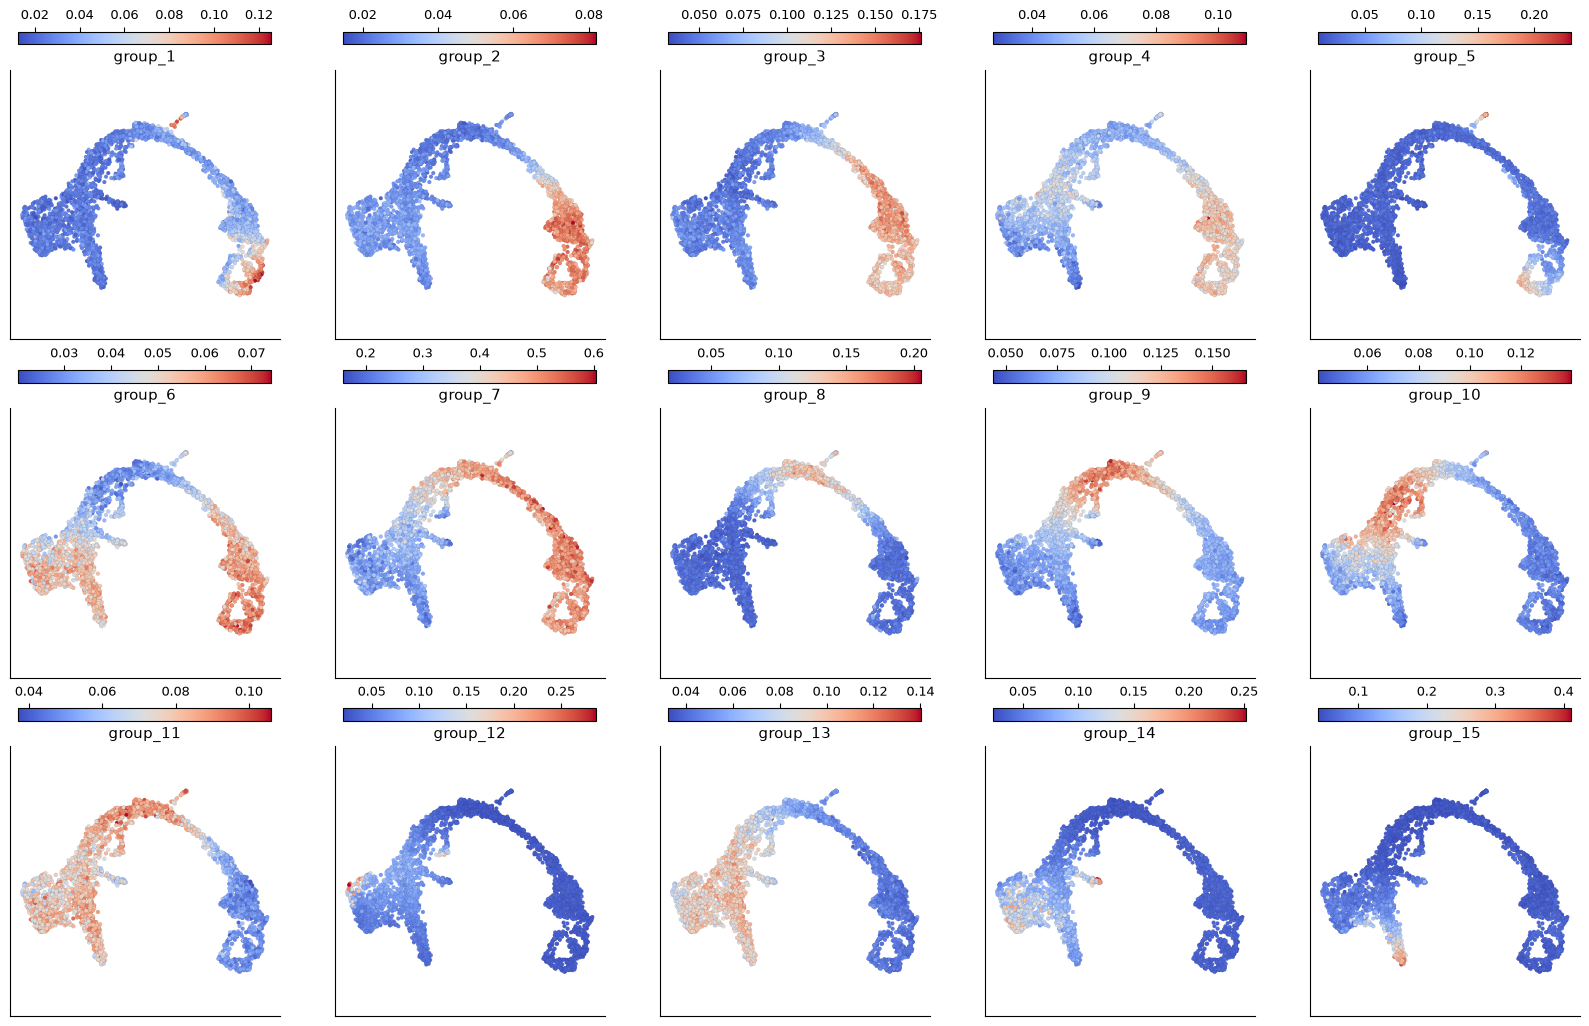

In [10]:
module_features = ds.PTIME_MODULES.feats.fetch_all('names').tolist()
ds.plots.embedding(
    from_assay='PTIME_MODULES',
    layout_key='RNA_UMAP',
    color_by=module_features,
    n_columns=5,
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

In [11]:
ds.run_marker_search(group_key='clusters')

In [12]:
cell_cluster_markers = ds.get_markers(
    group_key='clusters',
    group_id='Beta',
).feature_name

cell_cluster_markers.head()

0     Sytl4
1      Ins2
2     G6pc2
3    Adra2a
4       Gip
Name: feature_name, dtype: object

In [13]:
ptime_feat_clusts = ds.RNA.feats.to_pandas_dataframe(
    columns=['names', 'pseudotime_clusters']
)

beta_marker_names = set(cell_cluster_markers)
assigned = ptime_feat_clusts[ptime_feat_clusts.pseudotime_clusters != -1]
module_overlap = assigned.groupby('pseudotime_clusters')['names'].apply(
    lambda names: len(set(names) & beta_marker_names)
)
beta_module = int(module_overlap.idxmax())
beta_module

15

In [14]:
ptime_based_markers = ptime_feat_clusts.names[
    ptime_feat_clusts.pseudotime_clusters == beta_module
]
ptime_based_markers.head()

19     Arfgef1
25       Tram1
55      Sdhaf4
87       Uggt1
102       Coa5
Name: names, dtype: object

In [15]:
# Number of genes captured by each approach
ptime_based_markers.shape, cell_cluster_markers.shape

((954,), (119,))

In [16]:
# Number of genes shared by both approaches, compared by gene name
len(set(ptime_based_markers) & set(cell_cluster_markers))

56

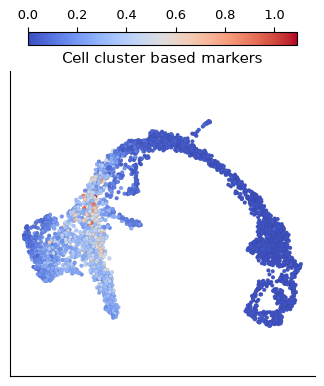

In [17]:
available_names = set(ptime_feat_clusts.names)
cell_only = sorted(
    (set(cell_cluster_markers) - set(ptime_based_markers)) & available_names
)
ds.cells.insert(
    column_name='Cell cluster based markers',
    values=ds.RNA.mean_features(cell_only),
    overwrite=True,
)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='Cell cluster based markers',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)

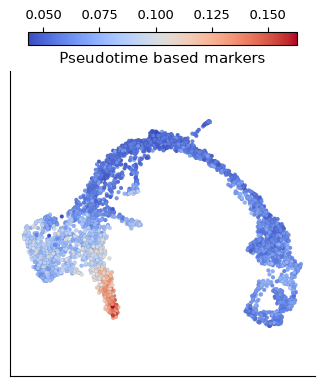

In [18]:
ptime_only = sorted(
    (set(ptime_based_markers) - set(cell_cluster_markers)) & available_names
)
ds.cells.insert(
    column_name='Pseudotime based markers',
    values=ds.RNA.mean_features(ptime_only),
    overwrite=True,
)

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='Pseudotime based markers',
    color_scale=splt.ColorScale(cmap='coolwarm'),
)